In [ ]:
from models import MIL_model, MLP_encoder, MaxAggergation, AttentionAggregation, GatedAttentionAggregation
from training_utils import model_run, set_seed
from evaluation_utils import evaluate_accuracy
from CustomDataloader import CustomLoader
from CellsData import CellsData

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

import pandas as pd
import numpy as np
import random

from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

from sklearn.linear_model import LogisticRegression, RidgeClassifier, RidgeClassifierCV, LassoCV, LogisticRegressionCV
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, LabelBinarizer, PolynomialFeatures
from sklearn.datasets import fetch_openml
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector as selector
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import pickle
from sklearn.model_selection import KFold, StratifiedKFold


In [ ]:
train_set = CellsData(split="train")
val_set = CellsData(split="val")
test_set = CellsData(split="test")

The entire datatset contains 146 bags.


In [ ]:
#train set
X_sparse_max = []
X_sparse_mean = []

X_embed_max = []
X_embed_mean = []

y_train = []

#test set
X_test_sparse_max = []
X_test_sparse_mean = []

X_test_embed_max = []
X_test_embed_mean = []

y_test = []

for el in train_set:
    X_sparse_max.append(np.max(el['bag'].to_dense().numpy(), axis = 0))
    X_sparse_mean.append(np.sum(el['bag'].to_dense().numpy(), axis = 0))

    X_embed_max.append(np.max(el['bag_embed'].to_dense().numpy(), axis = 0))
    X_embed_mean.append(np.sum(el['bag_embed'].to_dense().numpy(), axis = 0))

    y_train.append(el['y'].numpy())

for el in val_set:
    X_sparse_max.append(np.max(el['bag'].to_dense().numpy(), axis = 0))
    X_sparse_mean.append(np.sum(el['bag'].to_dense().numpy(), axis = 0))

    X_embed_max.append(np.max(el['bag_embed'].to_dense().numpy(), axis = 0))
    X_embed_mean.append(np.sum(el['bag_embed'].to_dense().numpy(), axis = 0))

    y_train.append(el['y'].numpy())

for el in test_set:
    X_test_sparse_max.append(np.max(el['bag'].to_dense().numpy(), axis = 0))
    X_test_sparse_mean.append(np.sum(el['bag'].to_dense().numpy(), axis = 0))

    X_test_embed_max.append(np.max(el['bag_embed'].to_dense().numpy(), axis = 0))
    X_test_embed_mean.append(np.sum(el['bag_embed'].to_dense().numpy(), axis = 0))

    y_test.append(el['y'].numpy())

X_sparse_max = np.array(X_sparse_max)
X_sparse_mean = np.array(X_sparse_mean)

X_embed_max = np.array(X_embed_max)
X_embed_mean = np.array(X_embed_mean)

y_train = np.array(y_train)[:, 1]

#test set
X_test_sparse_max = np.array(X_test_sparse_max)
X_test_sparse_mean = np.array(X_test_sparse_mean)

X_test_embed_max = np.array(X_test_embed_max)
X_test_embed_mean = np.array(X_embed_mean)

y_test = np.array(y_test)[:, 1]

In [ ]:
result_dict = dict()
clfs = dict()
options = dict()

options['Ridge'] = RidgeClassifierCV(alphas = (0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000), cv = 5, class_weight='balanced', fit_intercept = True)
options['Lasso'] = LogisticRegressionCV(penalty='l1', Cs = (0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000), cv = 5, solver='saga', max_iter = 1000)
options['Elastic Net'] = LogisticRegressionCV(penalty='elasticnet', Cs = (0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000), l1_ratios = [0.1, 0.5, 1], cv = 5, solver='saga', max_iter = 1000)
options['SVM'] = SVC(C = 100, class_weight='balanced')
options['Tree'] = DecisionTreeClassifier(max_depth = 30, class_weight='balanced')
options['Random Forest'] = RandomForestClassifier(n_estimators = 50, max_depth = 5, class_weight='balanced')



for classifier in options.keys():
    clf = options[classifier]
    scores = cross_validate(
        clf, X_sparse_max, y_train, scoring="balanced_accuracy", cv=StratifiedKFold(n_splits=5, shuffle=True)
    )

    print(classifier)
    mean = scores["test_score"].mean()
    sem = stats.sem(scores["test_score"])

    print(f"Mean Balanced Accuracy: {mean:.3f} +/- {sem:.3f}")
    acc_random = 0.125
    print(f"Balanced Accuracy with Random Labels: {acc_random:.3f}")

    result_dict[classifier] = (mean, sem)
    clfs[classifier] = clf


Ridge
Mean Balanced Accuracy: 0.485 +/- 0.046
Balanced Accuracy with Random Labels: 0.125


/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anacond

Lasso
Mean Balanced Accuracy: 0.444 +/- 0.035
Balanced Accuracy with Random Labels: 0.125


/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anacond

Elastic Net
Mean Balanced Accuracy: 0.508 +/- 0.008
Balanced Accuracy with Random Labels: 0.125
SVM
Mean Balanced Accuracy: 0.477 +/- 0.047
Balanced Accuracy with Random Labels: 0.125
Tree
Mean Balanced Accuracy: 0.506 +/- 0.040
Balanced Accuracy with Random Labels: 0.125
Random Forest
Mean Balanced Accuracy: 0.525 +/- 0.014
Balanced Accuracy with Random Labels: 0.125


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/tmp/ipykernel_29258/4003174285.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(('0%', '20%', '40%', '60%', '80%', '100%'))


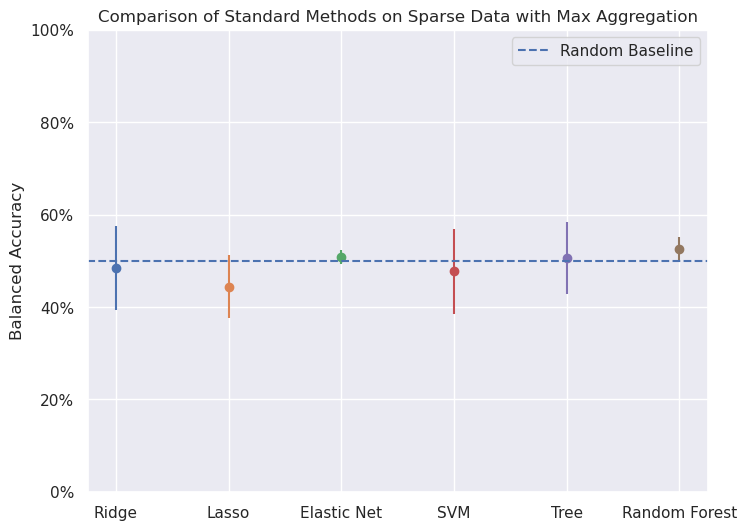

In [ ]:
fig, ax = plt.subplots(figsize = (8, 6))

counter = 0
for key, value in result_dict.items():
    if key != 'MLP':
        ax.scatter(counter, value[0])
        ax.errorbar(counter, value[0], 1.96*value[1])
        counter +=1
    else:
        ax.scatter(counter, value[0])
        ax.errorbar(counter, value[0], errors)
        counter +=1


ax.set_ylim((0, 1))
ax.legend()

ax.set_title("Comparison of Standard Methods on Sparse Data with Max Aggregation")
ax.set_xticks(range(len(result_dict.keys())))
ax.set_xticklabels(result_dict.keys())
ax.set_ylabel('Balanced Accuracy')
ax.set_yticklabels(('0%', '20%', '40%', '60%', '80%', '100%'))
ax.axhline(0.5, xmin=-1, xmax = 5, linestyle = '--', label = 'Random Baseline')
ax.legend()

In [ ]:
result_dict = dict()
clfs = dict()
options = dict()

options['Ridge'] = RidgeClassifierCV(alphas = (0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000), cv = 5, class_weight='balanced', fit_intercept = True)
options['Lasso'] = LogisticRegressionCV(penalty='l1', Cs = (0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000), cv = 5, solver='saga', max_iter = 1000)
options['Elastic Net'] = LogisticRegressionCV(penalty='elasticnet', Cs = (0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000), l1_ratios = [0.1, 0.5, 1], cv = 5, solver='saga', max_iter = 1000)
options['SVM'] = SVC(C = 100, class_weight='balanced')
options['Tree'] = DecisionTreeClassifier(max_depth = 30, class_weight='balanced')
options['Random Forest'] = RandomForestClassifier(n_estimators = 50, max_depth = 5, class_weight='balanced')



for classifier in options.keys():
    clf = options[classifier]
    scores = cross_validate(
        clf, X_sparse_mean, y_train, scoring="balanced_accuracy", cv=StratifiedKFold(n_splits=5, shuffle=True)
    )

    print(classifier)
    mean = scores["test_score"].mean()
    sem = stats.sem(scores["test_score"])

    print(f"Mean Balanced Accuracy: {mean:.3f} +/- {sem:.3f}")
    acc_random = 0.125
    print(f"Balanced Accuracy with Random Labels: {acc_random:.3f}")

    result_dict[classifier] = (mean, sem)
    clfs[classifier] = clf


/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:239: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:239: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:239: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:239: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(
/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py:239: UserWarning: Singular matrix in solving dual problem. Using least-squares solut

Ridge
Mean Balanced Accuracy: 0.608 +/- 0.028
Balanced Accuracy with Random Labels: 0.125


/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anacond

Lasso
Mean Balanced Accuracy: 0.512 +/- 0.039
Balanced Accuracy with Random Labels: 0.125


/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anacond

Elastic Net
Mean Balanced Accuracy: 0.497 +/- 0.026
Balanced Accuracy with Random Labels: 0.125
SVM
Mean Balanced Accuracy: 0.549 +/- 0.062
Balanced Accuracy with Random Labels: 0.125
Tree
Mean Balanced Accuracy: 0.468 +/- 0.049
Balanced Accuracy with Random Labels: 0.125
Random Forest
Mean Balanced Accuracy: 0.562 +/- 0.029
Balanced Accuracy with Random Labels: 0.125


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


/tmp/ipykernel_29258/1250551793.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(('0%', '20%', '40%', '60%', '80%', '100%'))


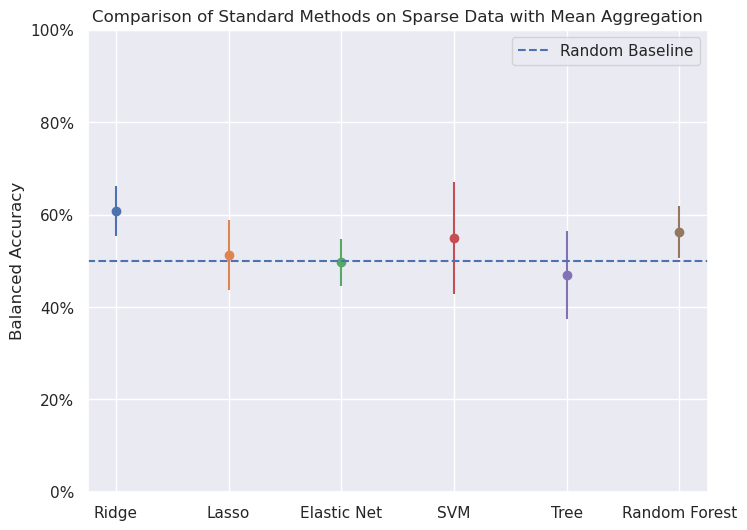

In [ ]:
fig, ax = plt.subplots(figsize = (8, 6))

counter = 0
for key, value in result_dict.items():
    if key != 'MLP':
        ax.scatter(counter, value[0])
        ax.errorbar(counter, value[0], 1.96*value[1])
        counter +=1
    else:
        ax.scatter(counter, value[0])
        ax.errorbar(counter, value[0], errors)
        counter +=1


ax.set_ylim((0, 1))
ax.legend()

ax.set_title("Comparison of Standard Methods on Sparse Data with Mean Aggregation")
ax.set_xticks(range(len(result_dict.keys())))
ax.set_xticklabels(result_dict.keys())
ax.set_ylabel('Balanced Accuracy')
ax.set_yticklabels(('0%', '20%', '40%', '60%', '80%', '100%'))
ax.axhline(0.5, xmin=-1, xmax = 5, linestyle = '--', label = 'Random Baseline')
ax.legend()

In [ ]:
result_dict = dict()
clfs = dict()
options = dict()

options['Ridge'] = RidgeClassifierCV(alphas = (0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000), cv = 5, class_weight='balanced', fit_intercept = True)
options['Lasso'] = LogisticRegressionCV(penalty='l1', Cs = (0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000), cv = 5, solver='saga', max_iter = 1000)
options['Elastic Net'] = LogisticRegressionCV(penalty='elasticnet', Cs = (0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000), l1_ratios = [0.1, 0.5, 1], cv = 5, solver='saga', max_iter = 1000)
options['SVM'] = SVC(C = 100, class_weight='balanced')
options['Tree'] = DecisionTreeClassifier(max_depth = 30, class_weight='balanced')
options['Random Forest'] = RandomForestClassifier(n_estimators = 50, max_depth = 5, class_weight='balanced')



for classifier in options.keys():
    clf = options[classifier]
    scores = cross_validate(
        clf, X_embed_max, y_train, scoring="balanced_accuracy", cv=StratifiedKFold(n_splits=5, shuffle=True)
    )

    print(classifier)
    mean = scores["test_score"].mean()
    sem = stats.sem(scores["test_score"])

    print(f"Mean Balanced Accuracy: {mean:.3f} +/- {sem:.3f}")
    acc_random = 0.125
    print(f"Balanced Accuracy with Random Labels: {acc_random:.3f}")

    result_dict[classifier] = (mean, sem)
    clfs[classifier] = clf

Ridge
Mean Balanced Accuracy: 0.461 +/- 0.032
Balanced Accuracy with Random Labels: 0.125


/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anacond

Lasso
Mean Balanced Accuracy: 0.482 +/- 0.018
Balanced Accuracy with Random Labels: 0.125


/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anacond

Elastic Net
Mean Balanced Accuracy: 0.500 +/- 0.000
Balanced Accuracy with Random Labels: 0.125
SVM
Mean Balanced Accuracy: 0.462 +/- 0.063
Balanced Accuracy with Random Labels: 0.125
Tree
Mean Balanced Accuracy: 0.455 +/- 0.029
Balanced Accuracy with Random Labels: 0.125
Random Forest
Mean Balanced Accuracy: 0.525 +/- 0.033
Balanced Accuracy with Random Labels: 0.125


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


/tmp/ipykernel_29258/2626603520.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(('0%', '20%', '40%', '60%', '80%', '100%'))


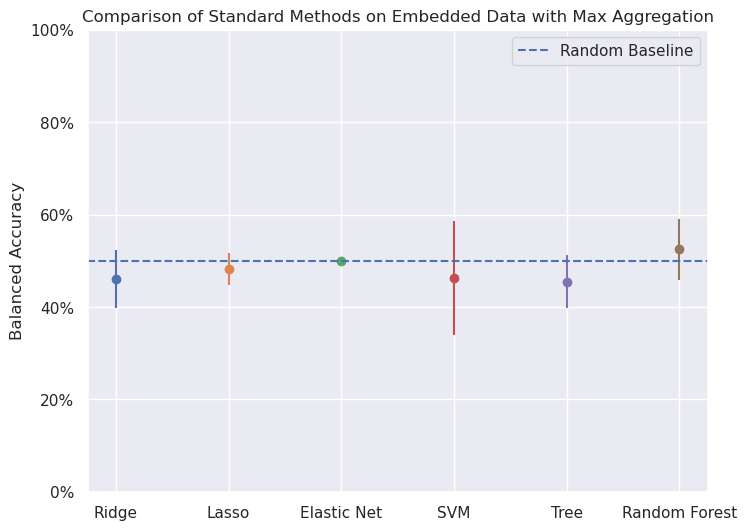

In [ ]:
fig, ax = plt.subplots(figsize = (8, 6))

counter = 0
for key, value in result_dict.items():
    if key != 'MLP':
        ax.scatter(counter, value[0])
        ax.errorbar(counter, value[0], 1.96*value[1])
        counter +=1
    else:
        ax.scatter(counter, value[0])
        ax.errorbar(counter, value[0], errors)
        counter +=1


ax.set_ylim((0, 1))
ax.legend()

ax.set_title("Comparison of Standard Methods on Embedded Data with Max Aggregation")
ax.set_xticks(range(len(result_dict.keys())))
ax.set_xticklabels(result_dict.keys())
ax.set_ylabel('Balanced Accuracy')
ax.set_yticklabels(('0%', '20%', '40%', '60%', '80%', '100%'))
ax.axhline(0.5, xmin=-1, xmax = 5, linestyle = '--', label = 'Random Baseline')
ax.legend()

In [ ]:
result_dict = dict()
clfs = dict()
options = dict()

options['Ridge'] = RidgeClassifierCV(alphas = (0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000), cv = 5, class_weight='balanced', fit_intercept = True)
options['Lasso'] = LogisticRegressionCV(penalty='l1', Cs = (0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000), cv = 5, solver='saga', max_iter = 1000)
options['Elastic Net'] = LogisticRegressionCV(penalty='elasticnet', Cs = (0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000), l1_ratios = [0.1, 0.5, 1], cv = 5, solver='saga', max_iter = 1000)
options['SVM'] = SVC(C = 100, class_weight='balanced')
options['Tree'] = DecisionTreeClassifier(max_depth = 30, class_weight='balanced')
options['Random Forest'] = RandomForestClassifier(n_estimators = 50, max_depth = 5, class_weight='balanced')



for classifier in options.keys():
    clf = options[classifier]
    scores = cross_validate(
        clf, X_embed_max, y_train, scoring="balanced_accuracy", cv=StratifiedKFold(n_splits=5, shuffle=True)
    )

    print(classifier)
    mean = scores["test_score"].mean()
    sem = stats.sem(scores["test_score"])

    print(f"Mean Balanced Accuracy: {mean:.3f} +/- {sem:.3f}")
    acc_random = 0.125
    print(f"Balanced Accuracy with Random Labels: {acc_random:.3f}")

    result_dict[classifier] = (mean, sem)
    clfs[classifier] = clf

Ridge
Mean Balanced Accuracy: 0.510 +/- 0.043
Balanced Accuracy with Random Labels: 0.125


/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anacond

Lasso
Mean Balanced Accuracy: 0.465 +/- 0.021
Balanced Accuracy with Random Labels: 0.125


/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anaconda3/envs/mil/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/viktor/anacond

Elastic Net
Mean Balanced Accuracy: 0.497 +/- 0.003
Balanced Accuracy with Random Labels: 0.125
SVM
Mean Balanced Accuracy: 0.543 +/- 0.040
Balanced Accuracy with Random Labels: 0.125
Tree
Mean Balanced Accuracy: 0.470 +/- 0.043
Balanced Accuracy with Random Labels: 0.125
Random Forest
Mean Balanced Accuracy: 0.508 +/- 0.059
Balanced Accuracy with Random Labels: 0.125


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/tmp/ipykernel_29258/62223836.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(('0%', '20%', '40%', '60%', '80%', '100%'))


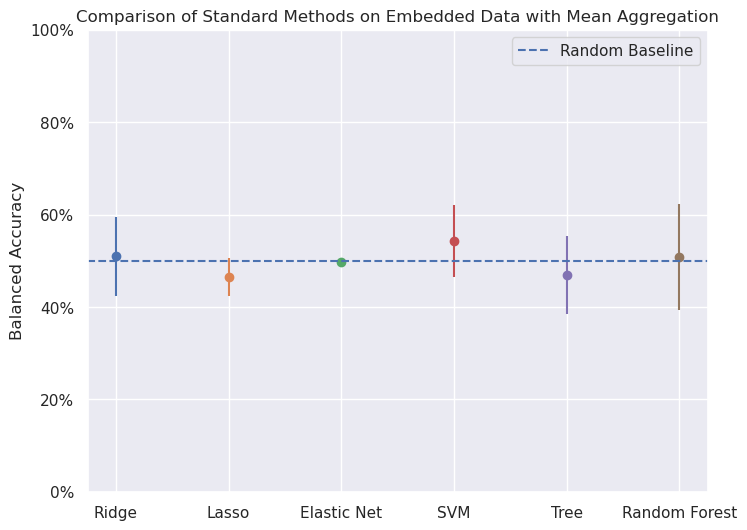

In [ ]:
fig, ax = plt.subplots(figsize = (8, 6))

counter = 0
for key, value in result_dict.items():
    if key != 'MLP':
        ax.scatter(counter, value[0])
        ax.errorbar(counter, value[0], 1.96*value[1])
        counter +=1
    else:
        ax.scatter(counter, value[0])
        ax.errorbar(counter, value[0], errors)
        counter +=1


ax.set_ylim((0, 1))
ax.legend()

ax.set_title("Comparison of Standard Methods on Embedded Data with Mean Aggregation")
ax.set_xticks(range(len(result_dict.keys())))
ax.set_xticklabels(result_dict.keys())
ax.set_ylabel('Balanced Accuracy')
ax.set_yticklabels(('0%', '20%', '40%', '60%', '80%', '100%'))
ax.axhline(0.5, xmin=-1, xmax = 5, linestyle = '--', label = 'Random Baseline')
ax.legend()